Import all the necessary packages 

In [1]:
# all the necessary pytorch packages
import torch 
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader, Subset

# cross val
from sklearn.model_selection import StratifiedKFold

# hpo library
import optuna
from optuna.samplers import RandomSampler


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import json 
import random 

import os

import sys

import time
from pathlib import Path

# assume notebook being run from assignment folder
ASSIGNMENT_DIR = Path.cwd()
BASELINE_NOTEBOOK = ASSIGNMENT_DIR / "baseline.ipynb"
SUPPORT_DIR = ASSIGNMENT_DIR / "WF-data and support code"
FIGURE_DIR = ASSIGNMENT_DIR /"figures"

os.chdir(SUPPORT_DIR)

from support import load_dataset

device = ('mps' if torch.backends.mps.is_available()
          else 'cuda' if torch.cuda.is_available()
          else 'cpu')

/Users/tommcgovern/miniconda3/envs/dmai-mps/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set the seeding to make the results reproducible 

In [2]:
SEED = 42

def set_seed(seed):
    ' make the randomness as reproducible as possible'
    random.seed(seed)
    np.random.seed(seed)

    # Pytorch cpu random gen
    torch.manual_seed(seed)

    # Pytorch gpu random gen, 
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
set_seed(SEED)

Find `CNN`, `train_one_epoch` and `evaluate` from the baseline solution. Don't run the full thing as this is all we need 

In [3]:
def find_baseline_def(marker):
    'execute one cell from baseline identified by a unique marker'

    # open the notebook as a json file 
    with open(BASELINE_NOTEBOOK) as f:
        baseline_nb = json.load(f)

    # look through every cell til we find the marker 
    for cell in baseline_nb["cells"]:
        # skip markdown cells
        if cell.get("cell_type") != "code":
            continue

        # join the list of strings to turn them back to pythn code    
        source = ''.join(cell.get("source", []))

        if marker in source:
            # run the selected cell in notebooks global namespace. 
            exec(source, globals())
            print(f'Loaded from baseline: {marker}')
            return 

# load all of the definitions
find_baseline_def('class CNN(nn.Module):')
find_baseline_def('def train_one_epoch')
find_baseline_def('def evaluate')



Loaded from baseline: class CNN(nn.Module):
Loaded from baseline: def train_one_epoch
Loaded from baseline: def evaluate


Load only the data needed for HPO

In [4]:
train_dataset, test_dataset = load_dataset()

# the integer class labels for each image type
labels = np.array(train_dataset.targets)

# the human readable class names
class_names = train_dataset.classes

We search over the following 5 hyperparameters:
- `learning rate`
- `batch rate`
- `base filters`
- `dropout`
- `hidden units`

The ranges were all centred (roughly) around the baseline model
This dictionary doesn't get used directly by Optuna. Just helps everyone see the search space (especially Ernst). 

In [5]:
SEARCH_SPACE_DESCRIPTION = {
    # Use log uniform as learning rates often differ by larger rates
    "lr": 'log-uniform [1e-4, 3e-3]',

    # larger than 32 doesnt really make sense as only 136 image
    "batch_size": '[8, 16, 32]',

    # this is converted to conv_channels = (base_fitlers, 2*base_filters)
    'base_filters': '[16, 32, 48, 64]',

    # no dropout may overfit badly so dont go to 0
    'dropout': 'uniform [0.1, 0.6]',

    # size of layer after conv 
    'hidden': '[64, 128, 256]'
}

SEARCH_SPACE_DESCRIPTION

{'lr': 'log-uniform [1e-4, 3e-3]',
 'batch_size': '[8, 16, 32]',
 'base_filters': '[16, 32, 48, 64]',
 'dropout': 'uniform [0.1, 0.6]',
 'hidden': '[64, 128, 256]'}

Turn these hyperparameters into arguments 

In [6]:
def make_baseline_config(params):
    '''convert 5 sampled HPO values into the arguments for baseline.CNN'''
    base_filters = int(params['base_filters'])
    return {'lr': float(params['lr']),
            'batch_size': int(params['batch_size']),
             'base_filters': base_filters,
              'dropout': float(params['dropout']),
               'hidden': int(params['hidden']),
                'conv_channels': (base_filters, 2*base_filters) }





For each sampled configuration, we train 5 fresh models
- four folds for training 
- one for validation

In [7]:
def calculate_cv(config, trial_number = None):
    '''calculate the 5 fold cross validation score for one hyper parameter setting'''

    fold_scores = []
    fold_results = []
    # go thru all 5 folds for this one config
    for fold_number, (train_idx, val_idx) in enumerate(splits, start=1):

        set_seed(SEED +  fold_number)

        # create fold specific datasets w/o copying image tensors
        trainset_CV = Subset(train_dataset, train_idx)
        valset_CV = Subset(train_dataset, val_idx)

        print('Training fold size:', len(trainset_CV))
        print('Validation fold size:', len(valset_CV))

        # create data loader for this fold
        train_loader = DataLoader(dataset = trainset_CV,
                                  batch_size= config['batch_size'],
                                  shuffle = True)
        
        val_loader = DataLoader(dataset = valset_CV, 
                                batch_size= config['batch_size'],
                                shuffle = False)

        # define new model, loss func, optimizer for every fold
        model_CV = CNN(
            conv_channels = config['conv_channels'],
            hidden = config['hidden'],
            dropout = config['dropout'],
        ).to(device)

        # loss func for classification of logits
        criterion = nn.CrossEntropyLoss()

        # same as baseline
        optimizer = optim.Adam(model_CV.parameters(), lr = config['lr'])

        best_val_acc = 0.0
        best_epoch = 0

        # train the model for this fold 
        for epoch in range(1, CV_EPOCHS + 1):
            train_loss, train_acc = train_one_epoch(model_CV, train_loader,
                                                    optimizer,
                                                    criterion, device)
            val_loss, val_acc = evaluate(model_CV, val_loader, 
                                                criterion, device)
            print("Epoch:", epoch)
            print("Train Loss:", train_loss)
            print("Train accuracy:", 100.0 * train_acc)
            print("Validation Loss:", val_loss)
            print("Validation accuracy:", 100.0 * val_acc)

            # use best validation acc reached during this fold 
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch

        print('Best validation accuracy in this fold', 100*best_val_acc)
        print('Best epoch in the fold', best_epoch)

        fold_scores.append(best_val_acc)

        
        fold_results.append({
            "trial": trial_number,
            "fold": fold_number,
            "best_val_acc": best_val_acc,
            "best_epoch": best_epoch,
            "lr": config["lr"],
            "batch_size": config["batch_size"],
            "base_filters": config["base_filters"],
            "conv_channels": str(config["conv_channels"]),
            "dropout": config["dropout"],
            "hidden": config["hidden"],
        })
    mean_CVscore = float(np.mean(fold_scores))
    std_CVscore = float(np.std(fold_scores))

    print("Mean CV accuracy:", mean_CVscore)
    print("Standard deviation CV accuracy:", std_CVscore)

    return mean_CVscore, std_CVscore, fold_scores, fold_results






Random search with 5 fold cross validation 

In [8]:
sampler = RandomSampler(seed = SEED)

# default values 
# total fold models trained = TRIALS * SPLITS
N_TRIALS = 10 
CV_EPOCHS = 10
N_SPLITS = 5

# keeps the ng/ok balance similar 
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state= SEED)
splits = list(cv.split(np.zeros(len(labels)), labels))

# print the validation class counts to confimr the folds are balanced
for fold, (_, val_idx) in enumerate(splits, start=1):
    fold_labels = labels[val_idx]
    counts = {class_names[i]: int((fold_labels == i).sum()) for i in range(len(class_names))}
    print(f"Fold {fold} validation counts:", counts)


Fold 1 validation counts: {'ng': 14, 'ok': 14}
Fold 2 validation counts: {'ng': 14, 'ok': 13}
Fold 3 validation counts: {'ng': 14, 'ok': 13}
Fold 4 validation counts: {'ng': 13, 'ok': 14}
Fold 5 validation counts: {'ng': 13, 'ok': 14}


In [9]:
def sample_config(trial):
    """Sample five hyperparameters and convert them to baseline-compatible config."""
    # trial.suggest_ is how Optuna chooses values
    # with RandomSampler, these choices are random within the specified spaces
    params = {
        "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        "base_filters": trial.suggest_categorical("base_filters", [16, 32, 48, 64]),
        "dropout": trial.suggest_float("dropout", 0.10, 0.60),
        "hidden": trial.suggest_categorical("hidden", [64, 128, 256]),
    }

    # convert the five sampled values into the exact arguments needed by the
    # baseline CNN and training code
    return make_baseline_config(params)


# detailed: one row per trial per fold
all_trial_fold_results = []

def objective(trial):
    config = sample_config(trial)

    print("NEW RANDOM SEARCH ITERATION:", trial.number)
    print('Hyperparameters:', config)

    # calculate 5 fold cv score for this random config
    mean_acc, std_acc, fold_scores, fold_results = calculate_cv(config, trial_number= trial.number)

    # store fold levels results for extraction 
    all_trial_fold_results.extend(fold_results)

    # user_attrs are extra values saved inside the Optuna trial need for df later
    trial.set_user_attr("mean_val_acc", mean_acc)
    trial.set_user_attr("std_val_acc", std_acc)
    trial.set_user_attr("fold_scores", fold_scores)

    print(f"Trial {trial.number}: mean val acc = {mean_acc:.3f} +/- {std_acc:.3f}")
    return mean_acc

study = optuna.create_study(
    # want highest possible validation accuracy
    direction = 'maximize',
    sampler = RandomSampler(seed=SEED),
    study_name="random_search_5fold"
)

# run this search and take time
tic = time.perf_counter()
study.optimize(objective, n_trials= N_TRIALS)
toc = time.perf_counter()

print("\nBest trial:", study.best_trial.number)
print("Best mean validation accuracy:", study.best_value)
print("Best hyperparameters:", study.best_params)
print("Best baseline config:", make_baseline_config(study.best_params))
print("Total time passed:", toc - tic, "seconds")

[I 2026-06-01 09:59:23,295] A new study created in memory with name: random_search_5fold


NEW RANDOM SEARCH ITERATION: 0
Hyperparameters: {'lr': 0.00035747129226002455, 'batch_size': 8, 'base_filters': 64, 'dropout': 0.40055750587160444, 'hidden': 256, 'conv_channels': (64, 128)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.6987509065204196
Train accuracy: 50.0
Validation Loss: 0.6929315158299038
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.6936149266031053
Train accuracy: 46.2962962962963
Validation Loss: 0.6928418448993138
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6931836803754171
Train accuracy: 50.0
Validation Loss: 0.6922765714781625
Validation accuracy: 50.0
Epoch: 4
Train Loss: 0.6905425411683542
Train accuracy: 64.81481481481481
Validation Loss: 0.689142142023359
Validation accuracy: 57.14285714285714
Epoch: 5
Train Loss: 0.689456926451789
Train accuracy: 56.481481481481474
Validation Loss: 0.6745627692767552
Validation accuracy: 75.0
Epoch: 6
Train Loss: 0.6699728413864419
Train accuracy: 65.74074074074075
Validation Loss: 0.63

[I 2026-06-01 10:03:06,819] Trial 0 finished with value: 0.7939153439153439 and parameters: {'lr': 0.00035747129226002455, 'batch_size': 8, 'base_filters': 64, 'dropout': 0.40055750587160444, 'hidden': 256}. Best is trial 0 with value: 0.7939153439153439.


Epoch: 10
Train Loss: 0.5654453946909773
Train accuracy: 70.64220183486239
Validation Loss: 0.4631547326291049
Validation accuracy: 81.48148148148148
Best validation accuracy in this fold 92.5925925925926
Best epoch in the fold 9
Mean CV accuracy: 0.7939153439153439
Standard deviation CV accuracy: 0.07669402968192827
Trial 0: mean val acc = 0.794 +/- 0.077
NEW RANDOM SEARCH ITERATION: 1
Hyperparameters: {'lr': 0.0016967533607196547, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.40592644736118977, 'hidden': 256, 'conv_channels': (32, 64)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.7030011040193064
Train accuracy: 51.85185185185185
Validation Loss: 0.6966887542179653
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.692316660174617
Train accuracy: 53.70370370370371
Validation Loss: 0.6935549974441528
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6952885852919685
Train accuracy: 50.0
Validation Loss: 0.6935689875057766
Validation accuracy: 50.0
Epoch: 4


[I 2026-06-01 10:06:43,245] Trial 1 finished with value: 0.5074074074074074 and parameters: {'lr': 0.0016967533607196547, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.40592644736118977, 'hidden': 256}. Best is trial 0 with value: 0.7939153439153439.


...

Epoch: 10
Train Loss: 0.6930820192765752
Train accuracy: 54.12844036697248
Validation Loss: 0.6925055826151812
Validation accuracy: 48.148148148148145
Best validation accuracy in this fold 51.85185185185185
Best epoch in the fold 2
Mean CV accuracy: 0.6185185185185186
Standard deviation CV accuracy: 0.11688691731895925
Trial 7: mean val acc = 0.619 +/- 0.117
NEW RANDOM SEARCH ITERATION: 8
Hyperparameters: {'lr': 0.0005917520523090664, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.5537832369630465, 'hidden': 256, 'conv_channels': (32, 64)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.7064807768221255
Train accuracy: 50.0
Validation Loss: 0.693157970905304
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.6935653377462316
Train accuracy: 48.148148148148145
Validation Loss: 0.6931482468332563
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6934166572712086
Train accuracy: 50.0
Validation Loss: 0.6932487147194999
Validation accuracy: 50.0
Epoch: 4
Train Loss:

[I 2026-06-01 10:32:02,710] Trial 8 finished with value: 0.6174603174603175 and parameters: {'lr': 0.0005917520523090664, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.5537832369630465, 'hidden': 256}. Best is trial 2 with value: 0.830952380952381.


Epoch: 10
Train Loss: 0.6929571262193382
Train accuracy: 50.45871559633027
Validation Loss: 0.6934258827456722
Validation accuracy: 48.148148148148145
Best validation accuracy in this fold 48.148148148148145
Best epoch in the fold 1
Mean CV accuracy: 0.6174603174603175
Standard deviation CV accuracy: 0.11663756850771181
Trial 8: mean val acc = 0.617 +/- 0.117
NEW RANDOM SEARCH ITERATION: 9
Hyperparameters: {'lr': 0.00021775224101934056, 'batch_size': 16, 'base_filters': 16, 'dropout': 0.5018360384495573, 'hidden': 128, 'conv_channels': (16, 32)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.6974989926373517
Train accuracy: 44.44444444444444
Validation Loss: 0.6935211334909711
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.6940366714089005
Train accuracy: 49.074074074074076
Validation Loss: 0.6930286884307861
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.692805219579626
Train accuracy: 53.70370370370371
Validation Loss: 0.6929516196250916
Validation accura

[I 2026-06-01 10:35:34,679] Trial 9 finished with value: 0.5814814814814815 and parameters: {'lr': 0.00021775224101934056, 'batch_size': 16, 'base_filters': 16, 'dropout': 0.5018360384495573, 'hidden': 128}. Best is trial 2 with value: 0.830952380952381.


Epoch: 10
Train Loss: 0.6931005169492249
Train accuracy: 52.293577981651374
Validation Loss: 0.6933497234627053
Validation accuracy: 48.148148148148145
Best validation accuracy in this fold 51.85185185185185
Best epoch in the fold 2
Mean CV accuracy: 0.5814814814814815
Standard deviation CV accuracy: 0.10317324649766013
Trial 9: mean val acc = 0.581 +/- 0.103

Best trial: 2
Best mean validation accuracy: 0.830952380952381
Best hyperparameters: {'lr': 0.000471705203762518, 'batch_size': 8, 'base_filters': 48, 'dropout': 0.13252579649263976, 'hidden': 128}
Best baseline config: {'lr': 0.000471705203762518, 'batch_size': 8, 'base_filters': 48, 'dropout': 0.13252579649263976, 'hidden': 128, 'conv_channels': (48, 96)}
Total time passed: 2171.3787058750167 seconds


Save all the figures and results 

In [11]:
# convert the study into a df each row represents one random search
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "state"))

# convert manually collected fold details into a table each row reprentes one random search
folds_df = pd.DataFrame(all_trial_fold_results)

# save the files
trials_path = ASSIGNMENT_DIR / "random_search_results/random_search_trials.csv"
folds_path = ASSIGNMENT_DIR / "random_search_results/random_search_folds.csv"
best_config_path = ASSIGNMENT_DIR / "random_search_results/best_random_search_config.json"

trials_df.to_csv(trials_path, index=False)
folds_df.to_csv(folds_path, index=False)

# convert  best Optuna params into format needed by the baseline
best_baseline_config = make_baseline_config(study.best_params)

#  JSON file records the best result 
best_config = {
    "best_trial": study.best_trial.number,
    "mean_validation_accuracy": study.best_value,
    "five_hyperparameters": study.best_params,
    "baseline_model_arguments": {
        "conv_channels": best_baseline_config["conv_channels"],
        "hidden": best_baseline_config["hidden"],
        "dropout": best_baseline_config["dropout"],
    },
    "optimizer_arguments": {
        "lr": best_baseline_config["lr"],
    },
    "data_loader_arguments": {
        "batch_size": best_baseline_config["batch_size"],
    },
    "n_trials": N_TRIALS,
    "cv_epochs": CV_EPOCHS,
    "n_splits": N_SPLITS,
    "search_space": SEARCH_SPACE_DESCRIPTION,
}

# save the best configuration in a structured format
with open(best_config_path, "w") as f:
    json.dump(best_config, f, indent=2)

# show the best trials directly in the notebook
display(trials_df.sort_values("value", ascending=False).head(10))

,number,value,params_base_filters,params_batch_size,params_dropout,params_hidden,params_lr,user_attrs_fold_scores,user_attrs_mean_val_acc,user_attrs_std_val_acc,state
2,2,0.830952,48,8,0.132526,128,0.000472,"[0.8214285714285714, 0.7037037037037037, 0.777...",0.830952,0.086198,COMPLETE
5,5,0.808466,64,16,0.137275,64,0.000375,"[0.8571428571428571, 0.7777777777777778, 0.703...",0.808466,0.076190,COMPLETE
0,0,0.793915,64,8,0.400558,256,0.000357,"[0.8214285714285714, 0.7037037037037037, 0.777...",0.793915,0.076694,COMPLETE
3,3,0.793386,64,16,0.229390,64,0.000282,"[0.8928571428571429, 0.7777777777777778, 0.777...",0.793386,0.061455,COMPLETE
4,4,0.727249,16,16,0.144246,256,0.000642,"[0.8214285714285714, 0.7407407407407407, 0.777...",0.727249,0.107449,COMPLETE
6,6,0.684656,16,8,0.531552,64,0.000102,"[0.5714285714285714, 0.7777777777777778, 0.740...",0.684656,0.117627,COMPLETE
7,7,0.618519,16,16,0.480393,128,0.000288,"[0.5, 0.7407407407407407, 0.7777777777777778, ...",0.618519,0.116887,COMPLETE
8,8,0.617460,32,8,0.553783,256,0.000592,"[0.6428571428571429, 0.7407407407407407, 0.481...",0.617460,0.116638,COMPLETE
9,9,0.581481,16,16,0.501836,128,0.000218,"[0.5, 0.7407407407407407, 0.6666666666666666, ...",0.581481,0.103173,COMPLETE
1,1,0.507407,32,8,0.405926,256,0.001697,"[0.5, 0.5185185185185185, 0.48148148148148145,...",0.507407,0.014815,COMPLETE


Plots for the report 

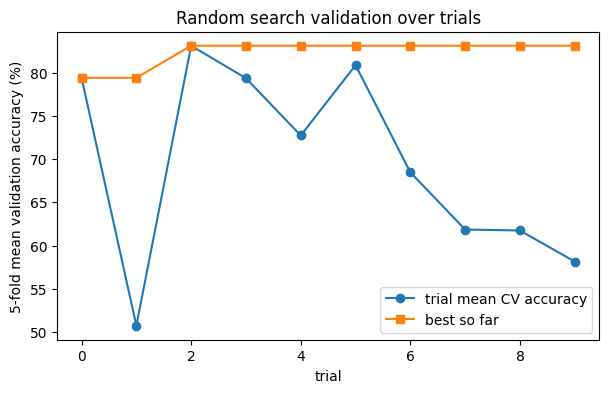

In [14]:
# sort by the numbers in which optuna ran them 
plot_df = trials_df.sort_values("number").copy()

plot_df['best_so_far'] = plot_df['value'].cummax()

plt.figure(figsize=(7,4))

# the raw sscore for each individual trail 
plt.plot(plot_df['number'], plot_df['value']*100, marker = 'o', label = 'trial mean CV accuracy')

# run best score found so far
plt.plot(plot_df['number'], plot_df['best_so_far']*100, marker = 's', label = 'best so far')
plt.xlabel('trial')
plt.ylabel('5-fold mean validation accuracy (%)')
plt.title('Random search validation over trials')
plt.legend()

# save the fig
curve_path = FIGURE_DIR/'random_search/random_search_validation_curve.png'
plt.savefig(curve_path, bbox_inches = 'tight', dpi = 150)
plt.show()

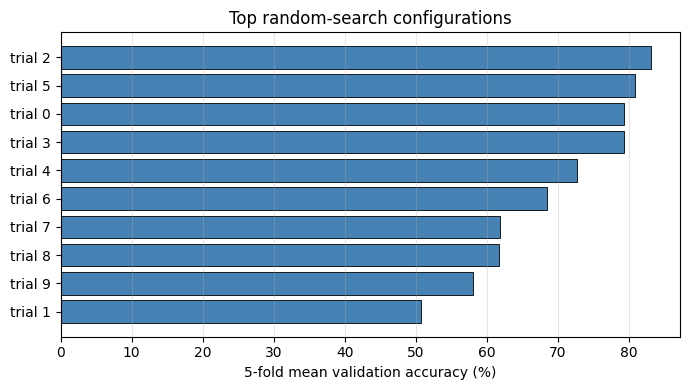

Saved: /Users/tommcgovern/Library/CloudStorage/OneDrive-TUEindhoven/Q4/Desicion Making/DMAI_assignment_2/figures/random_search/random_search_top_configs.png


In [15]:
# select the ten highest scoring trials
top_df = trials_df.sort_values("value", ascending=False).head(10).copy()

# readable labels for y axis
top_df["label"] = top_df["number"].apply(lambda n: f"trial {int(n)}")

plt.figure(figsize=(7, 4))

# horizontal barchat for final results
plt.barh(top_df["label"], top_df["value"] * 100, color="steelblue", edgecolor="black", linewidth=0.6)

# best trial at the top 
plt.gca().invert_yaxis()
plt.xlabel("5-fold mean validation accuracy (%)")
plt.title("Top random-search configurations")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
# save 
top_path = FIGURE_DIR / "random_search/random_search_top_configs.png"
plt.savefig(top_path, bbox_inches="tight", dpi=150)
plt.show()
print("Saved:", top_path)
